In [2]:
from pathlib import Path

# Use the exact path you gave
base_path = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")

# Folder structure
folders = [
    base_path,
    base_path / "data_raw",
    base_path / "data_clean",
    base_path / "sql",
    base_path / "python",
    base_path / "r",
    base_path / "outputs",
    base_path / "outputs" / "figures",
    base_path / "outputs" / "tables",
    base_path / "paper",
    base_path / "paper" / "drafts",
    base_path / "paper" / "references",
]

# Create folders
for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

# Starter files
files = {
    base_path / "README.md": "# UK Mortgage Risk Research\n\nProject for UK mortgage arrears, possessions, lending, and forecasting research.\n",
    base_path / "requirements.txt": "pandas\nnumpy\nmatplotlib\nseaborn\nplotly\nopenpyxl\njupyter\nstatsmodels\nscikit-learn\n",
    base_path / ".gitignore": "__pycache__/\n.ipynb_checkpoints/\n*.pyc\n.env\n",
    base_path / "sql" / "01_data_prep.sql": "-- SQL data preparation script\n",
    base_path / "python" / "01_data_collection.py": "# Python script for data collection and cleaning\n",
    base_path / "python" / "02_eda.py": "# Python script for exploratory data analysis\n",
    base_path / "python" / "03_modeling.py": "# Python script for predictive modeling\n",
    base_path / "python" / "04_forecasting.py": "# Python script for forecasting\n",
    base_path / "r" / "01_time_series_forecast.R": "# R script for time-series forecasting\n",
    base_path / "paper" / "outline.md": "# Research Paper Outline\n\n## Title\n## Abstract\n## Introduction\n## Data\n## Methodology\n## Results\n## Discussion\n## Conclusion\n",
}

# Create files only if they do not already exist
for file_path, content in files.items():
    if not file_path.exists():
        file_path.write_text(content, encoding="utf-8")

print("Project structure created successfully at:")
print(base_path)

print("\nFolders created:")
for folder in folders:
    print("-", folder)

print("\nFiles created:")
for file_path in files:
    print("-", file_path)

Project structure created successfully at:
C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research

Folders created:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_raw
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\sql
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\python
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\r
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\figures
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper\drafts
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper\references

Files created:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_

In [4]:
from pathlib import Path
import requests
import pandas as pd

# Base folder you gave earlier
base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
raw_dir = base / "data_raw" / "official_sources"
raw_dir.mkdir(parents=True, exist_ok=True)

# Official source files for the project
sources = [
    {
        "source_name": "Bank of England MLAR long-run summary tables",
        "file_name": "boe_mlar_longrun_summary.xlsx",
        "url": "https://www.bankofengland.co.uk/-/media/boe/files/statistics/mortgage-lenders-and-administrators/mlar-longrun-summary.xlsx",
        "notes": "Core quarterly mortgage lending and arrears series; includes 2025 Q4 in the long-run summary file."
    },
    {
        "source_name": "UK Finance Mortgage Arrears & Possessions Update Q4 2025",
        "file_name": "ukfinance_mortgage_arrears_possessions_q4_2025.pdf",
        "url": "https://www.ukfinance.org.uk/system/files/2026-02/UKF%20Mortgage%20Arrears%20%26%20Possessions%20Update%2012%20February%202026.pdf",
        "notes": "Industry arrears bands and possessions update for Q4 2025."
    },
    {
        "source_name": "FCA Mortgage Product Sales Data quarterly file",
        "file_name": "fca_psd_mortgages_quarterly_2024.xlsx",
        "url": "https://www.fca.org.uk/publication/data/product-sales-data-mortgages-quarterly-2024.xlsx",
        "notes": "Mortgage and remortgage product sales data by borrower, region, LTV and more."
    },
    {
        "source_name": "ONS UK House Price Index monthly price statistics",
        "file_name": "ons_uk_hpi_monthly_price_statistics_25mar2026.xlsx",
        "url": "https://www.ons.gov.uk/file?uri=%2Feconomy%2Finflationandpriceindices%2Fdatasets%2Fukhousepriceindexmonthlypricestatistics%2F25march2026%2Fukhousepriceindexmonthlypricestatistics.xlsx",
        "notes": "Latest ONS UK HPI monthly statistics file from the 25 March 2026 edition."
    },
]

headers = {
    "User-Agent": "Mozilla/5.0"
}

download_results = []

for src in sources:
    file_path = raw_dir / src["file_name"]
    try:
        response = requests.get(src["url"], headers=headers, timeout=60)
        response.raise_for_status()
        file_path.write_bytes(response.content)
        download_results.append({
            "source_name": src["source_name"],
            "file_name": src["file_name"],
            "status": "downloaded",
            "size_kb": round(file_path.stat().st_size / 1024, 2),
            "path": str(file_path),
            "notes": src["notes"],
            "url": src["url"]
        })
        print(f"Downloaded: {src['file_name']}")
    except Exception as e:
        download_results.append({
            "source_name": src["source_name"],
            "file_name": src["file_name"],
            "status": f"failed: {e}",
            "size_kb": None,
            "path": str(file_path),
            "notes": src["notes"],
            "url": src["url"]
        })
        print(f"Failed: {src['file_name']} -> {e}")

# Save a manifest so we keep track of provenance
manifest_path = raw_dir / "source_manifest.csv"
pd.DataFrame(download_results).to_csv(manifest_path, index=False)

print("\nSaved manifest:")
print(manifest_path)

print("\nFiles currently in official_sources:")
for p in sorted(raw_dir.iterdir()):
    print("-", p.name)

Downloaded: boe_mlar_longrun_summary.xlsx
Failed: ukfinance_mortgage_arrears_possessions_q4_2025.pdf -> 403 Client Error: Forbidden for url: https://www.ukfinance.org.uk/system/files/2026-02/UKF%20Mortgage%20Arrears%20%26%20Possessions%20Update%2012%20February%202026.pdf
Downloaded: fca_psd_mortgages_quarterly_2024.xlsx
Downloaded: ons_uk_hpi_monthly_price_statistics_25mar2026.xlsx

Saved manifest:
C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_raw\official_sources\source_manifest.csv

Files currently in official_sources:
- boe_mlar_longrun_summary.xlsx
- fca_psd_mortgages_quarterly_2024.xlsx
- ons_uk_hpi_monthly_price_statistics_25mar2026.xlsx
- source_manifest.csv


In [6]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
raw_dir = base / "data_raw" / "official_sources"
out_dir = base / "outputs" / "tables"
out_dir.mkdir(parents=True, exist_ok=True)

excel_files = list(raw_dir.glob("*.xlsx"))

inventory_rows = []

for file_path in excel_files:
    try:
        xls = pd.ExcelFile(file_path)
        for sheet in xls.sheet_names:
            inventory_rows.append({
                "file_name": file_path.name,
                "sheet_name": sheet
            })
    except Exception as e:
        inventory_rows.append({
            "file_name": file_path.name,
            "sheet_name": f"ERROR: {e}"
        })

inventory = pd.DataFrame(inventory_rows)
inventory_path = out_dir / "excel_sheet_inventory.csv"
inventory.to_csv(inventory_path, index=False)

print("Excel files found:")
for f in excel_files:
    print("-", f.name)

print("\nSheet inventory:")
print(inventory)

print(f"\nSaved inventory to:\n{inventory_path}")

Excel files found:
- boe_mlar_longrun_summary.xlsx
- fca_psd_mortgages_quarterly_2024.xlsx
- ons_uk_hpi_monthly_price_statistics_25mar2026.xlsx

Sheet inventory:
                                            file_name  \
0                       boe_mlar_longrun_summary.xlsx   
1                       boe_mlar_longrun_summary.xlsx   
2                       boe_mlar_longrun_summary.xlsx   
3                       boe_mlar_longrun_summary.xlsx   
4                       boe_mlar_longrun_summary.xlsx   
5               fca_psd_mortgages_quarterly_2024.xlsx   
6   ons_uk_hpi_monthly_price_statistics_25mar2026....   
7   ons_uk_hpi_monthly_price_statistics_25mar2026....   
8   ons_uk_hpi_monthly_price_statistics_25mar2026....   
9   ons_uk_hpi_monthly_price_statistics_25mar2026....   
10  ons_uk_hpi_monthly_price_statistics_25mar2026....   
11  ons_uk_hpi_monthly_price_statistics_25mar2026....   
12  ons_uk_hpi_monthly_price_statistics_25mar2026....   
13  ons_uk_hpi_monthly_price_statistics_

In [8]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
raw_dir = base / "data_raw" / "official_sources"
preview_dir = base / "outputs" / "tables" / "raw_previews"
preview_dir.mkdir(parents=True, exist_ok=True)

files_and_sheets = {
    "boe_mlar_longrun_summary.xlsx": [
        "Summary 1",
        "Summary 2",
        "Summary 3"
    ],
    "fca_psd_mortgages_quarterly_2024.xlsx": [
        "PSD Mortgage Quarterly Data"
    ],
    "ons_uk_hpi_monthly_price_statistics_25mar2026.xlsx": [
        "Contents",
        "1",
        "2",
        "3"
    ]
}

for file_name, sheet_list in files_and_sheets.items():
    file_path = raw_dir / file_name
    print(f"\n===== {file_name} =====")
    
    for sheet in sheet_list:
        try:
            df = pd.read_excel(file_path, sheet_name=sheet, header=None)
            preview = df.iloc[:15, :10]  # first 15 rows, first 10 columns
            
            safe_sheet = str(sheet).replace(" ", "_")
            out_file = preview_dir / f"{file_path.stem}__{safe_sheet}_preview.csv"
            preview.to_csv(out_file, index=False, header=False, encoding="utf-8-sig")
            
            print(f"\n--- Sheet: {sheet} ---")
            print(preview)
            print(f"Saved preview: {out_file.name}")
        except Exception as e:
            print(f"\n--- Sheet: {sheet} ---")
            print(f"ERROR: {e}")


===== boe_mlar_longrun_summary.xlsx =====

--- Sheet: Summary 1 ---
                                                    0   1  \
0                                                 NaN NaN   
1                                                 NaN NaN   
2                                                 NaN NaN   
3                                                 NaN NaN   
4                                                 NaN NaN   
5                                                 NaN NaN   
6                                           Table (1) NaN   
7                 Residential loans to individuals(a) NaN   
8                                                 NaN NaN   
9                                                 NaN NaN   
10  Residential loans to individuals:  Regulated a... NaN   
11                                                NaN NaN   
12                                                NaN NaN   
13                                                NaN NaN   
14              

In [10]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
raw_dir = base / "data_raw" / "official_sources"

targets = [
    ("boe_mlar_longrun_summary.xlsx", "Summary 1"),
    ("boe_mlar_longrun_summary.xlsx", "Summary 2"),
    ("boe_mlar_longrun_summary.xlsx", "Summary 3"),
    ("fca_psd_mortgages_quarterly_2024.xlsx", "PSD Mortgage Quarterly Data"),
    ("ons_uk_hpi_monthly_price_statistics_25mar2026.xlsx", "1"),
]

for file_name, sheet_name in targets:
    print("\n" + "="*100)
    print(f"FILE: {file_name}")
    print(f"SHEET: {sheet_name}")
    print("="*100)
    
    file_path = raw_dir / file_name
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    
    preview = df.iloc[10:41, :20].copy()
    preview.index = range(10, 10 + len(preview))  # show original-like row numbers
    
    pd.set_option("display.max_columns", 20)
    pd.set_option("display.width", 200)
    print(preview)


FILE: boe_mlar_longrun_summary.xlsx
SHEET: Summary 1
                                                   0   1                                                2           3          4           5           6          7          8          9          10  \
10  Residential loans to individuals:  Regulated a... NaN                                              NaN         NaN        NaN         NaN         NaN        NaN        NaN        NaN        NaN   
11                                                NaN NaN                                              NaN         NaN        NaN         NaN         NaN        NaN        NaN        NaN        NaN   
12                                                NaN NaN                                              NaN         NaN       2007         NaN         NaN        NaN       2008        NaN        NaN   
13                                                NaN NaN                                              NaN         NaN         Q1          Q2 

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
raw_dir = base / "data_raw" / "official_sources"
clean_dir = base / "data_clean"
clean_dir.mkdir(parents=True, exist_ok=True)

file_path = raw_dir / "boe_mlar_longrun_summary.xlsx"

def extract_boe_summary_long(file_path, sheet_name, year_row=12, quarter_row=13, data_start_row=15):
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # Identify quarter columns
    quarter_vals = df.iloc[quarter_row].astype(str).str.strip()
    quarter_cols = [c for c in df.columns if quarter_vals.get(c) in ["Q1", "Q2", "Q3", "Q4"]]

    if not quarter_cols:
        raise ValueError(f"No quarter columns found in {sheet_name}")

    # Build period labels from year row + quarter row
    years = df.iloc[year_row, quarter_cols].copy()
    years = years.ffill()

    periods = []
    for c in quarter_cols:
        y = years[c]
        q = df.iloc[quarter_row, c]
        try:
            y = int(float(y))
            periods.append(f"{y}-{str(q).strip()}")
        except:
            periods.append(None)

    period_map = dict(zip(quarter_cols, periods))

    records = []

    # Non-time columns are everything before the first detected quarter column
    first_q_col = min(quarter_cols)
    label_cols = [c for c in df.columns if c < first_q_col]

    for r in range(data_start_row, len(df)):
        row = df.iloc[r]

        # Build label from left-side text cells
        label_parts = []
        for c in label_cols:
            val = row[c]
            if pd.notna(val):
                sval = str(val).strip()
                if sval and sval.lower() != "nan":
                    label_parts.append(sval)

        series_label = " ".join(label_parts).strip()

        # Pull numeric values across quarter columns
        numeric_count = 0
        for c in quarter_cols:
            period = period_map[c]
            val = row[c]

            num = pd.to_numeric(pd.Series([val]), errors="coerce").iloc[0]
            if pd.notna(num):
                numeric_count += 1

            records.append({
                "sheet_name": sheet_name,
                "row_number": r,
                "series_label": series_label,
                "period": period,
                "value": num
            })

        # nothing special here; filtering happens later

    out = pd.DataFrame(records)

    # Keep only rows that have a useful label and at least 4 numeric points
    valid_rows = (
        out.groupby(["sheet_name", "row_number", "series_label"])["value"]
        .apply(lambda x: x.notna().sum())
        .reset_index(name="non_null_count")
    )

    valid_rows = valid_rows[
        valid_rows["series_label"].str.len().fillna(0) > 0
    ]
    valid_rows = valid_rows[valid_rows["non_null_count"] >= 4]

    out = out.merge(
        valid_rows[["sheet_name", "row_number", "series_label"]],
        on=["sheet_name", "row_number", "series_label"],
        how="inner"
    )

    out = out.dropna(subset=["period"]).sort_values(["sheet_name", "row_number", "period"]).reset_index(drop=True)
    return out

summary1_long = extract_boe_summary_long(file_path, "Summary 1")
summary2_long = extract_boe_summary_long(file_path, "Summary 2")

boe_long = pd.concat([summary1_long, summary2_long], ignore_index=True)

# Save outputs
summary1_path = clean_dir / "boe_summary1_long.csv"
summary2_path = clean_dir / "boe_summary2_long.csv"
combined_path = clean_dir / "boe_summary12_long.csv"

summary1_long.to_csv(summary1_path, index=False)
summary2_long.to_csv(summary2_path, index=False)
boe_long.to_csv(combined_path, index=False)

print("Saved:")
print("-", summary1_path)
print("-", summary2_path)
print("-", combined_path)

print("\nSummary 1 sample:")
print(summary1_long.head(20))

print("\nSummary 2 sample:")
print(summary2_long.head(20))

print("\nUnique series count:")
print("Summary 1:", summary1_long['series_label'].nunique())
print("Summary 2:", summary2_long['series_label'].nunique())

C:\Users\swapn\AppData\Local\Temp\ipykernel_8600\3353378367.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  years = years.ffill()
C:\Users\swapn\AppData\Local\Temp\ipykernel_8600\3353378367.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  years = years.ffill()


Saved:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\boe_summary1_long.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\boe_summary2_long.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\boe_summary12_long.csv

Summary 1 sample:
   sheet_name  row_number               series_label   period       value
0   Summary 1          16  Gross advances £ millions  2007-Q1   86432.163
1   Summary 1          16  Gross advances £ millions  2007-Q2   96694.881
2   Summary 1          16  Gross advances £ millions  2007-Q3  101979.980
3   Summary 1          16  Gross advances £ millions  2007-Q4   86608.823
4   Summary 1          16  Gross advances £ millions  2008-Q1   73365.331
5   Summary 1          16  Gross advances £ millions  2008-Q2   71629.616
6   Summary 1          16  Gross advances £ millions  2008-Q3   60583.695
7   Summary 1          16  Gross advances £ millions  2008-Q4   44823.241
8   Summary 1          16  Gros

In [14]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
clean_dir = base / "data_clean"
out_dir = base / "outputs" / "tables"
out_dir.mkdir(parents=True, exist_ok=True)

s1 = pd.read_csv(clean_dir / "boe_summary1_long.csv")
s2 = pd.read_csv(clean_dir / "boe_summary2_long.csv")

summary1_labels = pd.DataFrame({
    "sheet_name": "Summary 1",
    "series_label": sorted(s1["series_label"].dropna().unique())
})

summary2_labels = pd.DataFrame({
    "sheet_name": "Summary 2",
    "series_label": sorted(s2["series_label"].dropna().unique())
})

all_labels = pd.concat([summary1_labels, summary2_labels], ignore_index=True)

all_labels_path = out_dir / "boe_series_labels.csv"
all_labels.to_csv(all_labels_path, index=False)

print("SUMMARY 1 LABELS:")
for x in summary1_labels["series_label"]:
    print("-", x)

print("\nSUMMARY 2 LABELS:")
for x in summary2_labels["series_label"]:
    print("-", x)

print(f"\nSaved to: {all_labels_path}")

SUMMARY 1 LABELS:
- All loans Per cent
- Buy to let Per cent
- Fixed rate loans Per cent
- Further advances Per cent
- Gross advances £ millions
- House purchase Per cent
- Net advances £ millions
- New commitments £ millions
- Of which:  First time buyers Per cent
- Other (inc further advances) Per cent
- Other Per cent
- Per cent of business at fixed rates Per cent
- Remortgage Per cent
- Variable rate loans Per cent

SUMMARY 2 LABELS:
- < = 75% Per cent
- All over 90% Per cent
- Loans with impaired credit history Per cent
- Loans without impaired credit history Per cent
- Over 75 < = 90% Per cent
- Over 90 < = 95% Per cent
- Over 95% Per cent
- Overall residential loans to individuals £ millions
- Securitised £ millions
- Unsecuritised £ millions

Saved to: C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\boe_series_labels.csv


In [16]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
clean_dir = base / "data_clean"

boe = pd.read_csv(clean_dir / "boe_summary12_long.csv")

# Exact variables we want for the research project
series_map = {
    "Gross advances £ millions": "gross_advances_gbp_m",
    "Net advances £ millions": "net_advances_gbp_m",
    "New commitments £ millions": "new_commitments_gbp_m",
    "Per cent of business at fixed rates Per cent": "fixed_rate_share_pct",
    "All loans Per cent": "avg_interest_rate_all_loans_pct",
    "House purchase Per cent": "house_purchase_share_pct",
    "Of which: First time buyers Per cent": "first_time_buyer_share_pct",
    "Buy to let Per cent": "buy_to_let_share_pct",
    "Remortgage Per cent": "remortgage_share_pct",
    "< = 75% Per cent": "ltv_le_75_pct",
    "Over 75 < = 90% Per cent": "ltv_75_90_pct",
    "Over 90 < = 95% Per cent": "ltv_90_95_pct",
    "Over 95% Per cent": "ltv_gt_95_pct",
    "All over 90% Per cent": "ltv_gt_90_pct",
    "Loans with impaired credit history Per cent": "impaired_credit_history_pct",
    "Overall residential loans to individuals £ millions": "residential_loans_outstanding_gbp_m"
}

# Filter only chosen labels
boe_keep = boe[boe["series_label"].isin(series_map.keys())].copy()

# Rename to clean variable names
boe_keep["variable"] = boe_keep["series_label"].map(series_map)

# Pivot to quarterly wide format
boe_wide = (
    boe_keep.pivot_table(
        index="period",
        columns="variable",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

# Sort by period
boe_wide["year"] = boe_wide["period"].str.slice(0, 4).astype(int)
boe_wide["quarter_num"] = boe_wide["period"].str[-1].str.replace("Q", "", regex=False).astype(int)
boe_wide = boe_wide.sort_values(["year", "quarter_num"]).drop(columns=["year", "quarter_num"])

# Save outputs
long_path = clean_dir / "boe_research_long.csv"
wide_path = clean_dir / "boe_research_wide.csv"

boe_keep.to_csv(long_path, index=False)
boe_wide.to_csv(wide_path, index=False)

print("Saved:")
print("-", long_path)
print("-", wide_path)

print("\nVariables kept:")
for k, v in series_map.items():
    print(f"- {k}  -->  {v}")

print("\nWide dataset columns:")
print(list(boe_wide.columns))

print("\nWide dataset preview:")
print(boe_wide.head(12))

print("\nShape:")
print(boe_wide.shape)

Saved:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\boe_research_long.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\boe_research_wide.csv

Variables kept:
- Gross advances £ millions  -->  gross_advances_gbp_m
- Net advances £ millions  -->  net_advances_gbp_m
- New commitments £ millions  -->  new_commitments_gbp_m
- Per cent of business at fixed rates Per cent  -->  fixed_rate_share_pct
- All loans Per cent  -->  avg_interest_rate_all_loans_pct
- House purchase Per cent  -->  house_purchase_share_pct
- Of which: First time buyers Per cent  -->  first_time_buyer_share_pct
- Buy to let Per cent  -->  buy_to_let_share_pct
- Remortgage Per cent  -->  remortgage_share_pct
- < = 75% Per cent  -->  ltv_le_75_pct
- Over 75 < = 90% Per cent  -->  ltv_75_90_pct
- Over 90 < = 95% Per cent  -->  ltv_90_95_pct
- Over 95% Per cent  -->  ltv_gt_95_pct
- All over 90% Per cent  -->  ltv_gt_90_pct
- Loans with impaired credit history Per cent  -->  

In [18]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
raw_dir = base / "data_raw" / "official_sources"
out_dir = base / "outputs" / "tables" / "ons_previews"
out_dir.mkdir(parents=True, exist_ok=True)

file_path = raw_dir / "ons_uk_hpi_monthly_price_statistics_25mar2026.xlsx"

xls = pd.ExcelFile(file_path)
print("ONS sheet names:")
for s in xls.sheet_names:
    print("-", s)

target_sheets = ["Contents", "1", "2", "3"]

for sheet in target_sheets:
    if sheet in xls.sheet_names:
        print("\n" + "="*100)
        print(f"SHEET: {sheet}")
        print("="*100)
        
        df = pd.read_excel(file_path, sheet_name=sheet, header=None)
        preview = df.iloc[:20, :12].copy()
        
        print(preview)
        
        save_path = out_dir / f"ons_preview_{sheet}.csv"
        preview.to_csv(save_path, index=False, header=False, encoding="utf-8-sig")
        print(f"\nSaved preview: {save_path}")


ONS sheet names:
- Cover sheet
- Contents
- Notes
- 1
- 2
- 3
- 4
- 5
- 6
- 7
- 8
- 9
- 10
- 11

SHEET: Contents
                                                    0                                                  1
0                                   Table of contents                                                NaN
1   This worksheet contains one table. To access a...                                                NaN
2                                    Worksheet Number                                    Worksheet Title
3                                         Worksheet 1  UK House Price Index - Indices, countries and ...
4                                         Worksheet 2  UK House Price Index - Average Price (£s), cou...
5                                         Worksheet 3  UK House Price Index - Annual percentage chang...
6                                         Worksheet 4  House price level (£s) & Annual house price pe...
7                                         Works

In [20]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
raw_dir = base / "data_raw" / "official_sources"
clean_dir = base / "data_clean"
clean_dir.mkdir(parents=True, exist_ok=True)

file_path = raw_dir / "ons_uk_hpi_monthly_price_statistics_25mar2026.xlsx"

# Read sheet 3 where row 3 in Excel (header=2 in pandas) contains column names
ons = pd.read_excel(file_path, sheet_name="3", header=2)

# Keep only the UK-wide series
ons = ons[["Time period", "United Kingdom"]].copy()

# Rename columns
ons.columns = ["date", "uk_hpi_annual_change_pct"]

# Parse dates
ons["date"] = pd.to_datetime(ons["date"], format="%b %Y", errors="coerce")

# Clean numeric values
ons["uk_hpi_annual_change_pct"] = pd.to_numeric(ons["uk_hpi_annual_change_pct"], errors="coerce")

# Drop empty rows
ons = ons.dropna(subset=["date", "uk_hpi_annual_change_pct"]).copy()

# Create quarterly period label to match BOE format like 2011-Q1
ons["year"] = ons["date"].dt.year
ons["quarter_num"] = ons["date"].dt.quarter
ons["period"] = ons["year"].astype(str) + "-Q" + ons["quarter_num"].astype(str)

# Quarterly aggregation: average monthly annual growth within each quarter
ons_quarterly = (
    ons.groupby("period", as_index=False)["uk_hpi_annual_change_pct"]
    .mean()
)

# Sort properly
ons_quarterly["year"] = ons_quarterly["period"].str[:4].astype(int)
ons_quarterly["quarter_num"] = ons_quarterly["period"].str[-1].astype(int)
ons_quarterly = ons_quarterly.sort_values(["year", "quarter_num"]).drop(columns=["year", "quarter_num"])

# Save outputs
monthly_path = clean_dir / "ons_hpi_monthly_annual_change.csv"
quarterly_path = clean_dir / "ons_hpi_quarterly_annual_change.csv"

ons.to_csv(monthly_path, index=False)
ons_quarterly.to_csv(quarterly_path, index=False)

print("Saved:")
print("-", monthly_path)
print("-", quarterly_path)

print("\nMonthly preview:")
print(ons.head(12))

print("\nQuarterly preview:")
print(ons_quarterly.head(12))

print("\nQuarterly shape:")
print(ons_quarterly.shape)

Saved:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\ons_hpi_monthly_annual_change.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\ons_hpi_quarterly_annual_change.csv

Monthly preview:
         date  uk_hpi_annual_change_pct  year  quarter_num   period
0  2011-01-01                      -0.1  2011            1  2011-Q1
1  2011-02-01                      -0.9  2011            1  2011-Q1
2  2011-03-01                      -1.3  2011            1  2011-Q1
3  2011-04-01                      -1.1  2011            2  2011-Q2
4  2011-05-01                      -2.0  2011            2  2011-Q2
5  2011-06-01                      -2.3  2011            2  2011-Q2
6  2011-07-01                      -2.1  2011            3  2011-Q3
7  2011-08-01                      -2.0  2011            3  2011-Q3
8  2011-09-01                      -2.0  2011            3  2011-Q3
9  2011-10-01                      -2.0  2011            4  2011-Q4
10 2011-11-01    

In [22]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
clean_dir = base / "data_clean"
clean_dir.mkdir(parents=True, exist_ok=True)

# Load cleaned datasets
boe = pd.read_csv(clean_dir / "boe_research_wide.csv")
ons = pd.read_csv(clean_dir / "ons_hpi_quarterly_annual_change.csv")

# Merge on common quarterly period
master = boe.merge(ons, on="period", how="inner")

# Sort correctly
master["year"] = master["period"].str[:4].astype(int)
master["quarter_num"] = master["period"].str[-1].astype(int)
master = master.sort_values(["year", "quarter_num"]).reset_index(drop=True)

# Save
master_path = clean_dir / "uk_mortgage_risk_master_dataset.csv"
master.to_csv(master_path, index=False)

print("Saved:")
print("-", master_path)

print("\nMaster dataset preview:")
print(master.head(12))

print("\nColumns:")
print(list(master.columns))

print("\nShape:")
print(master.shape)

print("\nPeriod coverage:")
print("Start:", master["period"].min())
print("End:  ", master["period"].max())

print("\nMissing values by column:")
print(master.isna().sum())

Saved:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\uk_mortgage_risk_master_dataset.csv

Master dataset preview:
     period  avg_interest_rate_all_loans_pct  buy_to_let_share_pct  fixed_rate_share_pct  gross_advances_gbp_m  house_purchase_share_pct  impaired_credit_history_pct  ltv_75_90_pct  ltv_90_95_pct  \
0   2011-Q1                            3.648                  8.42                51.218             32984.725                     53.89                        0.327         24.178          1.248   
1   2011-Q2                            3.808                  8.98                56.023             36554.241                     59.13                        0.355         28.550          1.483   
2   2011-Q3                            3.591                  8.72                51.707             43568.227                     60.50                        0.370         28.729          1.356   
3   2011-Q4                            3.485                  9.48

In [24]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
raw_dir = base / "data_raw" / "official_sources"
clean_dir = base / "data_clean"
out_dir = base / "outputs" / "tables"
clean_dir.mkdir(parents=True, exist_ok=True)
out_dir.mkdir(parents=True, exist_ok=True)

file_path = raw_dir / "boe_mlar_longrun_summary.xlsx"

def extract_boe_summary_long(file_path, sheet_name, year_row=12, quarter_row=13, data_start_row=15):
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    quarter_vals = df.iloc[quarter_row].astype(str).str.strip()
    quarter_cols = [c for c in df.columns if quarter_vals.get(c) in ["Q1", "Q2", "Q3", "Q4"]]

    if not quarter_cols:
        raise ValueError(f"No quarter columns found in {sheet_name}")

    years = df.iloc[year_row, quarter_cols].copy()
    years = years.ffill()

    periods = []
    for c in quarter_cols:
        y = years[c]
        q = df.iloc[quarter_row, c]
        try:
            y = int(float(y))
            periods.append(f"{y}-{str(q).strip()}")
        except:
            periods.append(None)

    period_map = dict(zip(quarter_cols, periods))

    records = []
    first_q_col = min(quarter_cols)
    label_cols = [c for c in df.columns if c < first_q_col]

    for r in range(data_start_row, len(df)):
        row = df.iloc[r]

        label_parts = []
        for c in label_cols:
            val = row[c]
            if pd.notna(val):
                sval = str(val).strip()
                if sval and sval.lower() != "nan":
                    label_parts.append(sval)

        series_label = " ".join(label_parts).strip()

        for c in quarter_cols:
            val = pd.to_numeric(pd.Series([row[c]]), errors="coerce").iloc[0]
            records.append({
                "sheet_name": sheet_name,
                "row_number": r,
                "series_label": series_label,
                "period": period_map[c],
                "value": val
            })

    out = pd.DataFrame(records)

    valid_rows = (
        out.groupby(["sheet_name", "row_number", "series_label"])["value"]
        .apply(lambda x: x.notna().sum())
        .reset_index(name="non_null_count")
    )

    valid_rows = valid_rows[
        valid_rows["series_label"].str.len().fillna(0) > 0
    ]
    valid_rows = valid_rows[valid_rows["non_null_count"] >= 4]

    out = out.merge(
        valid_rows[["sheet_name", "row_number", "series_label"]],
        on=["sheet_name", "row_number", "series_label"],
        how="inner"
    )

    out = out.dropna(subset=["period"]).sort_values(["row_number", "period"]).reset_index(drop=True)
    return out

summary3 = extract_boe_summary_long(file_path, "Summary 3")

summary3_path = clean_dir / "boe_summary3_long.csv"
labels_path = out_dir / "boe_summary3_labels.csv"

summary3.to_csv(summary3_path, index=False)

labels = pd.DataFrame({
    "series_label": sorted(summary3["series_label"].dropna().unique())
})
labels.to_csv(labels_path, index=False)

print("Saved:")
print("-", summary3_path)
print("-", labels_path)

print("\nSUMMARY 3 LABELS:")
for x in labels["series_label"]:
    print("-", x)

print("\nSummary 3 sample:")
print(summary3.head(20))

print("\nUnique series count:")
print(summary3["series_label"].nunique())

C:\Users\swapn\AppData\Local\Temp\ipykernel_8600\3371884862.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  years = years.ffill()


Saved:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\boe_summary3_long.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\boe_summary3_labels.csv

SUMMARY 3 LABELS:
- 1.5 < 2.5% in arrears Per cent
- 10 % or more in arrears Per cent
- 2.5 < 5% in arrears Per cent
- 5 < 7.5% in arrears Per cent
- 7.5 < 10% in arrears Per cent
- Balances as per cent total loan balances Per cent
- Balances outstanding £ millions
- In possession Per cent
- Loan book:  balances outstanding £ millions
- Loan book:  number of loan accounts Units
- New possessions in quarter Units
- Number of loan accounts Units
- Possession sales in quarter Units
- Stock of possessions at end of quarter Units
- TOTAL Per cent
- Total (exc 1.5 < 2.5% band) Per cent

Summary 3 sample:
   sheet_name  row_number                   series_label   period     value
0   Summary 3          19  Number of loan accounts Units  2007-Q1  258659.0
1   Summary 3          19  Number of loan ac

In [26]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
clean_dir = base / "data_clean"
clean_dir.mkdir(parents=True, exist_ok=True)

s3 = pd.read_csv(clean_dir / "boe_summary3_long.csv")

target_map = {
    "Total (exc 1.5 < 2.5% band) Per cent": "serious_arrears_rate_pct",
    "TOTAL Per cent": "total_arrears_rate_pct",
    "New possessions in quarter Units": "new_possessions_units",
    "Stock of possessions at end of quarter Units": "stock_possessions_units"
}

s3_keep = s3[s3["series_label"].isin(target_map.keys())].copy()
s3_keep["variable"] = s3_keep["series_label"].map(target_map)

s3_wide = (
    s3_keep.pivot_table(
        index="period",
        columns="variable",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

# sort by quarter
s3_wide["year"] = s3_wide["period"].str[:4].astype(int)
s3_wide["quarter_num"] = s3_wide["period"].str[-1].astype(int)
s3_wide = s3_wide.sort_values(["year", "quarter_num"]).drop(columns=["year", "quarter_num"])

long_path = clean_dir / "boe_summary3_targets_long.csv"
wide_path = clean_dir / "boe_summary3_targets_wide.csv"

s3_keep.to_csv(long_path, index=False)
s3_wide.to_csv(wide_path, index=False)

print("Saved:")
print("-", long_path)
print("-", wide_path)

print("\nVariables kept:")
for k, v in target_map.items():
    print(f"- {k}  -->  {v}")

print("\nWide preview:")
print(s3_wide.head(12))

print("\nColumns:")
print(list(s3_wide.columns))

print("\nShape:")
print(s3_wide.shape)

print("\nMissing values by column:")
print(s3_wide.isna().sum())

Saved:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\boe_summary3_targets_long.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\boe_summary3_targets_wide.csv

Variables kept:
- Total (exc 1.5 < 2.5% band) Per cent  -->  serious_arrears_rate_pct
- TOTAL Per cent  -->  total_arrears_rate_pct
- New possessions in quarter Units  -->  new_possessions_units
- Stock of possessions at end of quarter Units  -->  stock_possessions_units

Wide preview:
variable   period  new_possessions_units  serious_arrears_rate_pct  stock_possessions_units  total_arrears_rate_pct
0         2007-Q1                 6472.0                     1.297                  12143.0                   2.059
1         2007-Q2                 6464.0                     1.318                  12581.0                   2.079
2         2007-Q3                 6838.0                     1.367                  12836.0                   2.132
3         2007-Q4                 8135.0 

In [28]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
clean_dir = base / "data_clean"
clean_dir.mkdir(parents=True, exist_ok=True)

# Load datasets
master = pd.read_csv(clean_dir / "uk_mortgage_risk_master_dataset.csv")
targets = pd.read_csv(clean_dir / "boe_summary3_targets_wide.csv")

# Merge on quarter
final_df = master.merge(targets, on="period", how="inner")

# Sort properly
final_df["year"] = final_df["period"].str[:4].astype(int)
final_df["quarter_num"] = final_df["period"].str[-1].astype(int)
final_df = final_df.sort_values(["year", "quarter_num"]).reset_index(drop=True)

# Save
final_path = clean_dir / "uk_mortgage_risk_final_research_dataset.csv"
final_df.to_csv(final_path, index=False)

print("Saved:")
print("-", final_path)

print("\nFinal dataset preview:")
print(final_df.head(12))

print("\nColumns:")
print(list(final_df.columns))

print("\nShape:")
print(final_df.shape)

print("\nPeriod coverage:")
print("Start:", final_df["period"].min())
print("End:  ", final_df["period"].max())

print("\nMissing values by column:")
print(final_df.isna().sum())

Saved:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\data_clean\uk_mortgage_risk_final_research_dataset.csv

Final dataset preview:
     period  avg_interest_rate_all_loans_pct  buy_to_let_share_pct  fixed_rate_share_pct  gross_advances_gbp_m  house_purchase_share_pct  impaired_credit_history_pct  ltv_75_90_pct  ltv_90_95_pct  \
0   2011-Q1                            3.648                  8.42                51.218             32984.725                     53.89                        0.327         24.178          1.248   
1   2011-Q2                            3.808                  8.98                56.023             36554.241                     59.13                        0.355         28.550          1.483   
2   2011-Q3                            3.591                  8.72                51.707             43568.227                     60.50                        0.370         28.729          1.356   
3   2011-Q4                            3.485               

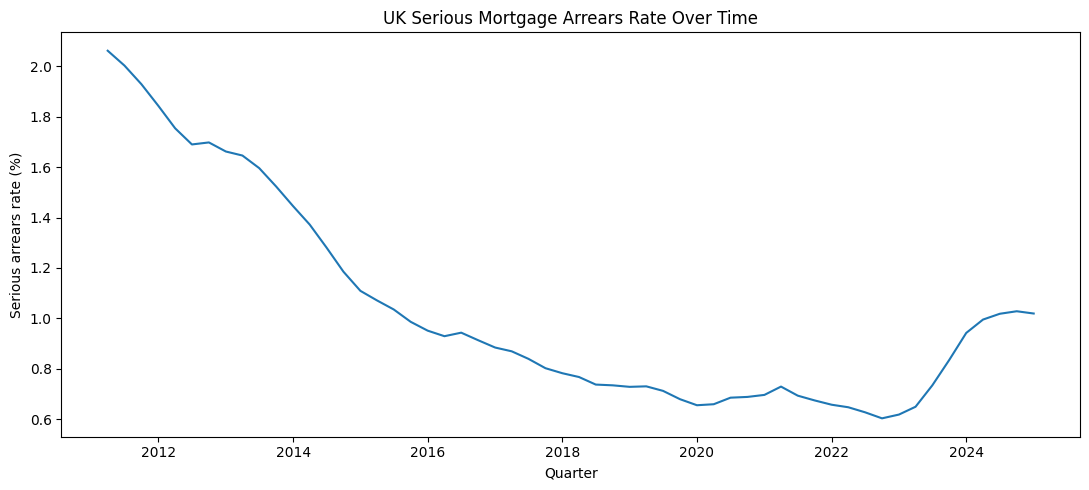

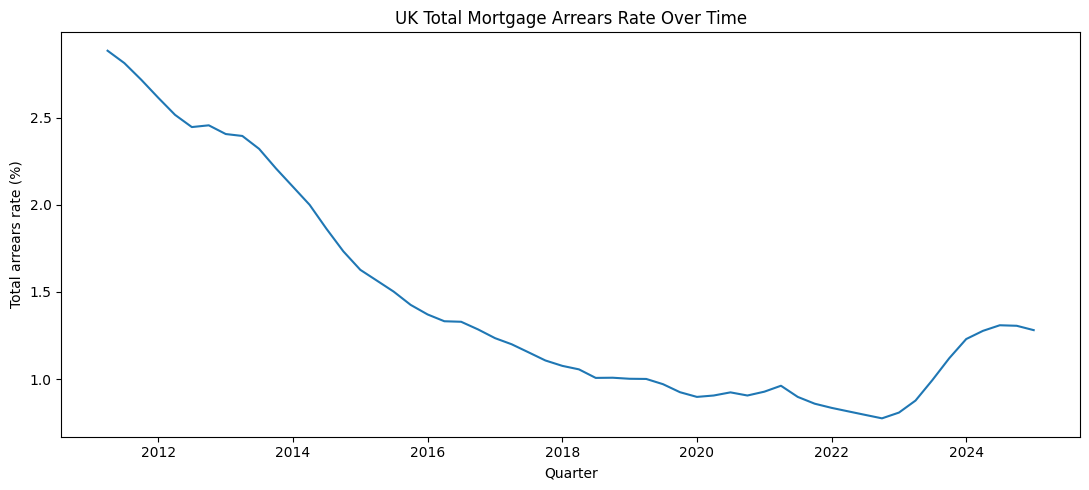

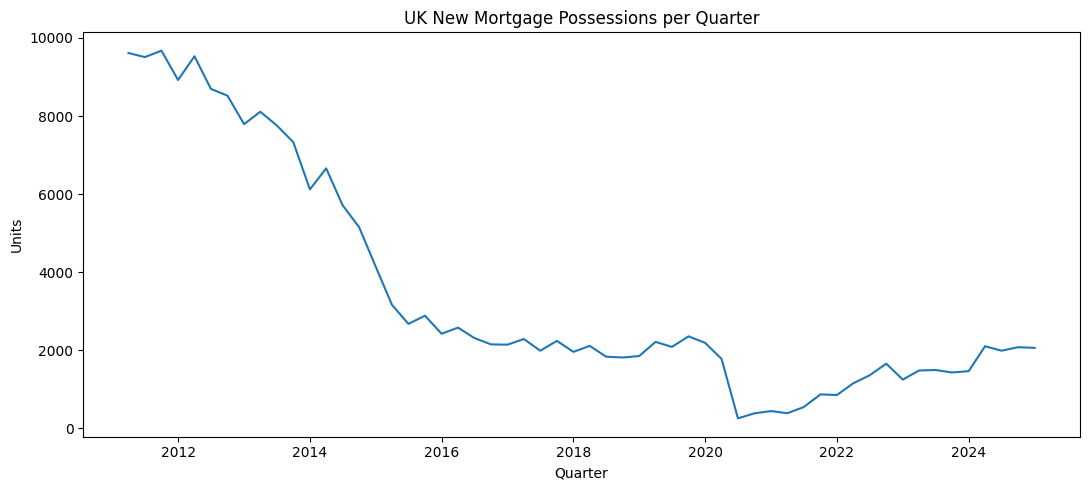

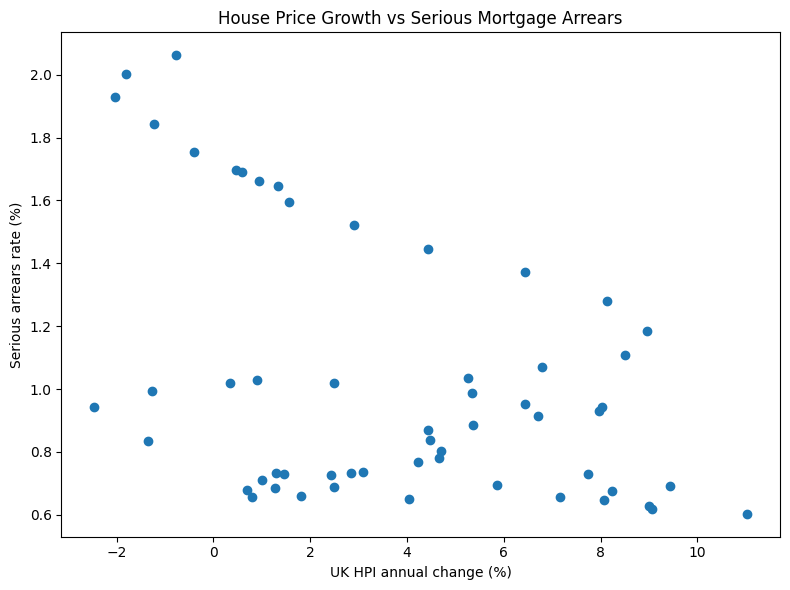

Saved tables:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\descriptive_summary_table.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\yearly_summary_table.csv

Saved figures:
- fig_01_serious_arrears_trend.png
- fig_02_total_arrears_trend.png
- fig_03_new_possessions_trend.png
- fig_04_hpi_vs_serious_arrears_scatter.png

Descriptive summary table preview:
                           variable  count          mean        median           min           max           std
0          serious_arrears_rate_pct   56.0      1.031071      0.898500      0.603000      2.062000      0.416378
1            total_arrears_rate_pct   56.0      1.434946      1.232500      0.775000      2.884000      0.623021
2             new_possessions_units   56.0   3451.910714   2141.500000    249.000000   9674.000000   2919.586691
3           stock_possessions_units   56.0   6501.071429   4358.000000   1583.000000  16262.000000   4463.219551
4   avg_interest_ra

In [30]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
clean_dir = base / "data_clean"
fig_dir = base / "outputs" / "figures"
tab_dir = base / "outputs" / "tables"

fig_dir.mkdir(parents=True, exist_ok=True)
tab_dir.mkdir(parents=True, exist_ok=True)

# Load final dataset
df = pd.read_csv(clean_dir / "uk_mortgage_risk_final_research_dataset.csv")

# Quarter date for plotting
df["period_q"] = pd.PeriodIndex(df["period"], freq="Q")
df["period_date"] = df["period_q"].dt.to_timestamp(how="end")

# -----------------------------
# 1. Descriptive summary table
# -----------------------------
summary_vars = [
    "serious_arrears_rate_pct",
    "total_arrears_rate_pct",
    "new_possessions_units",
    "stock_possessions_units",
    "avg_interest_rate_all_loans_pct",
    "uk_hpi_annual_change_pct",
    "gross_advances_gbp_m",
    "new_commitments_gbp_m",
    "fixed_rate_share_pct",
    "house_purchase_share_pct",
    "buy_to_let_share_pct",
    "remortgage_share_pct",
    "impaired_credit_history_pct",
    "ltv_gt_90_pct"
]

desc_table = (
    df[summary_vars]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

desc_path = tab_dir / "descriptive_summary_table.csv"
desc_table.to_csv(desc_path, index=False)

# -----------------------------
# 2. Yearly summary table
# -----------------------------
yearly_table = (
    df.groupby("year", as_index=False)
    .agg(
        serious_arrears_rate_avg=("serious_arrears_rate_pct", "mean"),
        total_arrears_rate_avg=("total_arrears_rate_pct", "mean"),
        new_possessions_total=("new_possessions_units", "sum"),
        stock_possessions_avg=("stock_possessions_units", "mean"),
        avg_interest_rate_avg=("avg_interest_rate_all_loans_pct", "mean"),
        uk_hpi_annual_change_avg=("uk_hpi_annual_change_pct", "mean"),
        gross_advances_total_gbp_m=("gross_advances_gbp_m", "sum"),
        new_commitments_total_gbp_m=("new_commitments_gbp_m", "sum"),
        fixed_rate_share_avg=("fixed_rate_share_pct", "mean"),
        ltv_gt_90_avg=("ltv_gt_90_pct", "mean"),
        impaired_credit_history_avg=("impaired_credit_history_pct", "mean")
    )
)

yearly_path = tab_dir / "yearly_summary_table.csv"
yearly_table.to_csv(yearly_path, index=False)

# -----------------------------
# 3. Chart: serious arrears trend
# -----------------------------
plt.figure(figsize=(11, 5))
plt.plot(df["period_date"], df["serious_arrears_rate_pct"])
plt.title("UK Serious Mortgage Arrears Rate Over Time")
plt.xlabel("Quarter")
plt.ylabel("Serious arrears rate (%)")
plt.tight_layout()
plt.savefig(fig_dir / "fig_01_serious_arrears_trend.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 4. Chart: total arrears trend
# -----------------------------
plt.figure(figsize=(11, 5))
plt.plot(df["period_date"], df["total_arrears_rate_pct"])
plt.title("UK Total Mortgage Arrears Rate Over Time")
plt.xlabel("Quarter")
plt.ylabel("Total arrears rate (%)")
plt.tight_layout()
plt.savefig(fig_dir / "fig_02_total_arrears_trend.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 5. Chart: new possessions trend
# -----------------------------
plt.figure(figsize=(11, 5))
plt.plot(df["period_date"], df["new_possessions_units"])
plt.title("UK New Mortgage Possessions per Quarter")
plt.xlabel("Quarter")
plt.ylabel("Units")
plt.tight_layout()
plt.savefig(fig_dir / "fig_03_new_possessions_trend.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 6. Chart: house price growth vs serious arrears
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(df["uk_hpi_annual_change_pct"], df["serious_arrears_rate_pct"])
plt.title("House Price Growth vs Serious Mortgage Arrears")
plt.xlabel("UK HPI annual change (%)")
plt.ylabel("Serious arrears rate (%)")
plt.tight_layout()
plt.savefig(fig_dir / "fig_04_hpi_vs_serious_arrears_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved tables:")
print("-", desc_path)
print("-", yearly_path)

print("\nSaved figures:")
for f in sorted(fig_dir.glob("fig_0*.png")):
    print("-", f.name)

print("\nDescriptive summary table preview:")
print(desc_table)

print("\nYearly summary table preview:")
print(yearly_table.head(10))

In [32]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
tab_dir = base / "outputs" / "tables"
paper_dir = base / "paper"
paper_dir.mkdir(parents=True, exist_ok=True)

desc = pd.read_csv(tab_dir / "descriptive_summary_table.csv")
yearly = pd.read_csv(tab_dir / "yearly_summary_table.csv")

def get_stat(df, var, col):
    return float(df.loc[df["variable"] == var, col].iloc[0])

# Main descriptive stats
serious_mean = get_stat(desc, "serious_arrears_rate_pct", "mean")
serious_min = get_stat(desc, "serious_arrears_rate_pct", "min")
serious_max = get_stat(desc, "serious_arrears_rate_pct", "max")

total_mean = get_stat(desc, "total_arrears_rate_pct", "mean")
poss_mean = get_stat(desc, "new_possessions_units", "mean")
poss_max = get_stat(desc, "new_possessions_units", "max")

rate_mean = get_stat(desc, "avg_interest_rate_all_loans_pct", "mean")
hpi_mean = get_stat(desc, "uk_hpi_annual_change_pct", "mean")
fixed_mean = get_stat(desc, "fixed_rate_share_pct", "mean")
ltv90_mean = get_stat(desc, "ltv_gt_90_pct", "mean")
impaired_mean = get_stat(desc, "impaired_credit_history_pct", "mean")

# Early and late year comparisons
early = yearly[yearly["year"] == yearly["year"].min()].iloc[0]
late = yearly[yearly["year"] == yearly["year"].max()].iloc[0]

notes = f"""# Results Section Notes

## 1. Overall descriptive pattern

The quarterly dataset shows that mortgage stress was present but not constant across the sample. The mean serious arrears rate was {serious_mean:.3f}%, while the mean total arrears rate was {total_mean:.3f}%. Serious arrears ranged from {serious_min:.3f}% to {serious_max:.3f}%, showing substantial variation over time.

The average number of new possessions per quarter was {poss_mean:,.0f}, with a peak quarterly value of {poss_max:,.0f}. This indicates that possession activity was episodically severe rather than stable across the sample.

Average mortgage pricing conditions were moderate over the full period, with the overall average interest rate on all loans at {rate_mean:.3f}%. The average annual UK house price change was {hpi_mean:.3f}%, indicating that the sample covers both weaker and stronger housing-market conditions.

Portfolio structure also changed materially across the period. The average fixed-rate share was {fixed_mean:.3f}%, while the average share of lending at high loan-to-value ratios above 90% was {ltv90_mean:.3f}%. The average share of lending involving impaired credit history was {impaired_mean:.3f}%.

## 2. Time pattern in arrears and possessions

The yearly summaries suggest a strong decline in mortgage stress after the early part of the sample. In {int(early["year"])}, the average serious arrears rate was {early["serious_arrears_rate_avg"]:.3f}% and total new possessions reached {early["new_possessions_total"]:,.0f}. By {int(late["year"])}, the average serious arrears rate had fallen to {late["serious_arrears_rate_avg"]:.3f}%, while new possessions totaled {late["new_possessions_total"]:,.0f}.

This pattern implies that the early 2010s represent a higher-stress phase, while later years show substantially improved arrears conditions. The charts of serious arrears, total arrears, and new possessions should be described as confirming this downward shift in mortgage distress over time.

## 3. Market structure and lending composition

The yearly table shows that fixed-rate lending increased strongly over time. This is important because a higher fixed-rate share can reduce short-run repayment sensitivity to interest-rate movements. At the same time, lending activity expanded: gross advances and new commitments were much higher in later years than in the early sample period.

High-LTV lending did not disappear, but it stayed limited relative to the full mortgage market. Impaired-credit-history lending remained a small share overall, although its variation over time may still be useful in explaining arrears dynamics.

## 4. Housing market conditions

House-price growth varied considerably across the sample, moving from negative territory in the early years to much stronger positive growth in later periods. This matters because weaker house-price growth may reduce borrower refinancing flexibility and increase stress in the mortgage book, while stronger price growth may support balance-sheet resilience.

The scatter plot between annual house-price growth and serious arrears should be described carefully as an exploratory relationship, not yet as causal proof. In the paper, this figure can be used to motivate the formal modeling section.

## 5. What these descriptive findings mean for the paper

These first results show that UK mortgage stress is associated with a broader macro-financial environment rather than a single variable. The descriptive evidence suggests that arrears and possessions evolved alongside changes in interest rates, lending composition, fixed-rate penetration, and housing-market conditions.

This provides a clear basis for the next stage of the paper: testing which of these factors are most strongly associated with serious arrears, total arrears, and possession activity in the UK mortgage market.
"""

out_path = paper_dir / "results_section_notes.md"
out_path.write_text(notes, encoding="utf-8")

print(f"Saved: {out_path}\n")
print(notes)

Saved: C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper\results_section_notes.md

# Results Section Notes

## 1. Overall descriptive pattern

The quarterly dataset shows that mortgage stress was present but not constant across the sample. The mean serious arrears rate was 1.031%, while the mean total arrears rate was 1.435%. Serious arrears ranged from 0.603% to 2.062%, showing substantial variation over time.

The average number of new possessions per quarter was 3,452, with a peak quarterly value of 9,674. This indicates that possession activity was episodically severe rather than stable across the sample.

Average mortgage pricing conditions were moderate over the full period, with the overall average interest rate on all loans at 3.034%. The average annual UK house price change was 3.749%, indicating that the sample covers both weaker and stronger housing-market conditions.

Portfolio structure also changed materially across the period. The average fixed-rate share wa

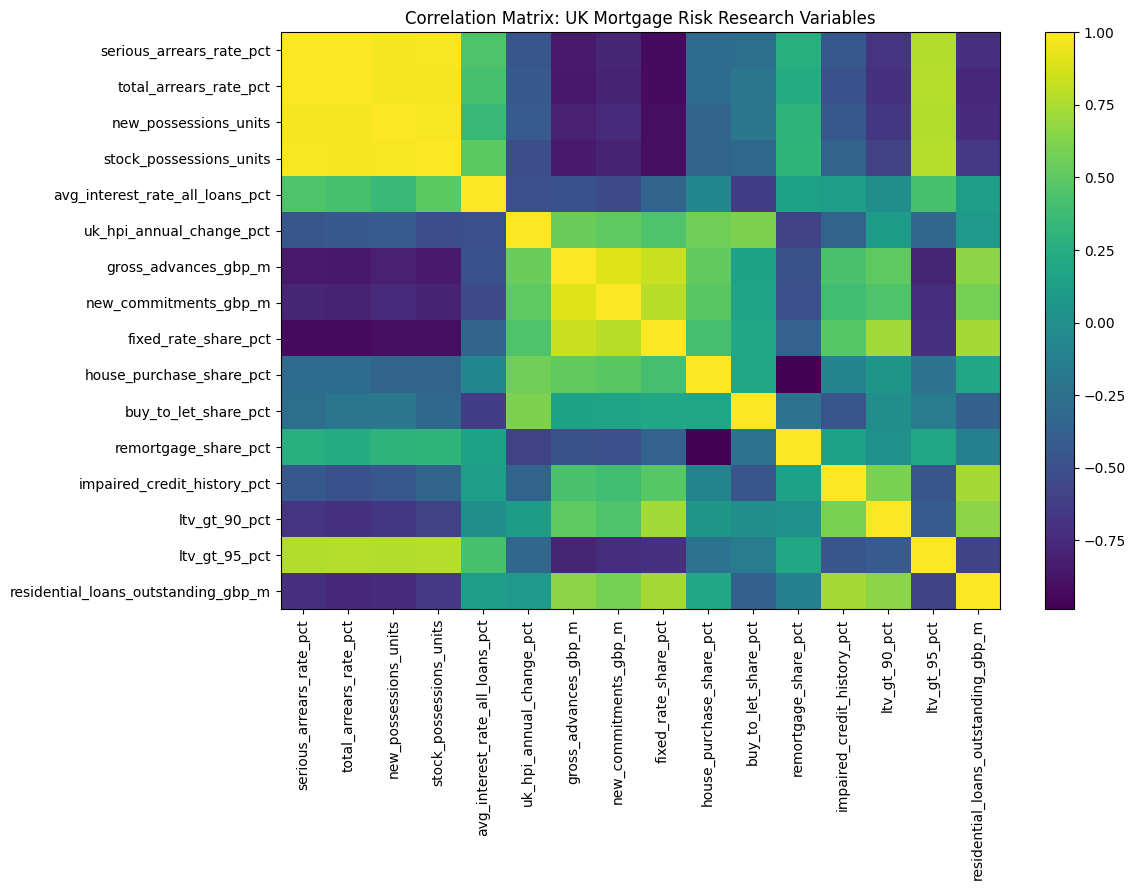

Saved tables:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\correlation_matrix.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\target_correlations.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\target_correlations_top8.csv

Saved figure:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\figures\fig_05_correlation_heatmap.png

Top 8 correlations for each target:
                      target                             variable  correlation  abs_correlation
0      new_possessions_units              stock_possessions_units     0.979355         0.979355
1      new_possessions_units               total_arrears_rate_pct     0.976079         0.976079
2      new_possessions_units             serious_arrears_rate_pct     0.969003         0.969003
3      new_possessions_units                 fixed_rate_share_pct    -0.915811         0.915811
4      new_possessions_units                 gross

In [34]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
clean_dir = base / "data_clean"
tab_dir = base / "outputs" / "tables"
fig_dir = base / "outputs" / "figures"
paper_dir = base / "paper"

tab_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
paper_dir.mkdir(parents=True, exist_ok=True)

# Load final dataset
df = pd.read_csv(clean_dir / "uk_mortgage_risk_final_research_dataset.csv")

# Variables for analysis
analysis_vars = [
    "serious_arrears_rate_pct",
    "total_arrears_rate_pct",
    "new_possessions_units",
    "stock_possessions_units",
    "avg_interest_rate_all_loans_pct",
    "uk_hpi_annual_change_pct",
    "gross_advances_gbp_m",
    "new_commitments_gbp_m",
    "fixed_rate_share_pct",
    "house_purchase_share_pct",
    "buy_to_let_share_pct",
    "remortgage_share_pct",
    "impaired_credit_history_pct",
    "ltv_gt_90_pct",
    "ltv_gt_95_pct",
    "residential_loans_outstanding_gbp_m"
]

corr = df[analysis_vars].corr(method="pearson")

# Save full correlation matrix
corr_path = tab_dir / "correlation_matrix.csv"
corr.to_csv(corr_path)

# Build target-focused table
targets = [
    "serious_arrears_rate_pct",
    "total_arrears_rate_pct",
    "new_possessions_units"
]

rows = []
for target in targets:
    for var in analysis_vars:
        if var != target:
            rows.append({
                "target": target,
                "variable": var,
                "correlation": corr.loc[target, var],
                "abs_correlation": abs(corr.loc[target, var])
            })

target_corr = pd.DataFrame(rows).sort_values(
    ["target", "abs_correlation"], ascending=[True, False]
)

target_corr_path = tab_dir / "target_correlations.csv"
target_corr.to_csv(target_corr_path, index=False)

# Save top 8 for each target separately
top_corr = (
    target_corr.groupby("target", group_keys=False)
    .head(8)
    .reset_index(drop=True)
)

top_corr_path = tab_dir / "target_correlations_top8.csv"
top_corr.to_csv(top_corr_path, index=False)

# Heatmap using matplotlib only
plt.figure(figsize=(12, 9))
im = plt.imshow(corr.values, aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix: UK Mortgage Risk Research Variables")
plt.tight_layout()
heatmap_path = fig_dir / "fig_05_correlation_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

# Write quick notes file
notes_lines = []
for target in targets:
    sub = target_corr[target_corr["target"] == target].head(5)
    notes_lines.append(f"\nTop correlations for {target}:\n")
    for _, r in sub.iterrows():
        notes_lines.append(
            f"- {r['variable']}: correlation = {r['correlation']:.3f}"
        )

notes_text = "# Correlation Notes\n" + "\n".join(notes_lines)
notes_path = paper_dir / "correlation_notes.md"
notes_path.write_text(notes_text, encoding="utf-8")

print("Saved tables:")
print("-", corr_path)
print("-", target_corr_path)
print("-", top_corr_path)

print("\nSaved figure:")
print("-", heatmap_path)

print("\nTop 8 correlations for each target:")
print(top_corr)

print("\nCorrelation notes saved to:")
print("-", notes_path)

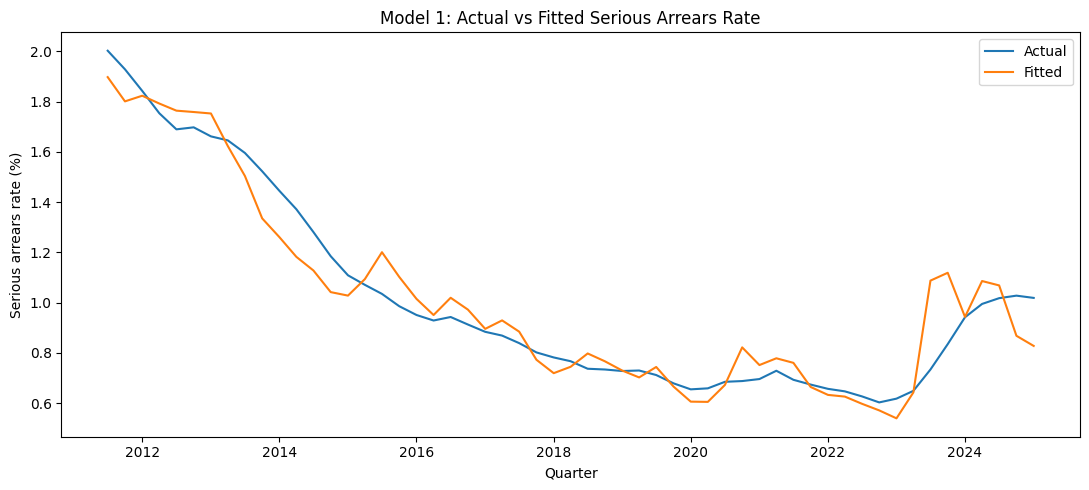

Saved tables:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\model1_serious_arrears_coefficients.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\model1_serious_arrears_fit_stats.csv

Saved summary:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper\model1_serious_arrears_summary.txt

Saved figure:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\figures\fig_06_model1_actual_vs_fitted_serious_arrears.png

Model fit stats:
                       model_name  n_obs  r_squared  adj_r_squared        aic        bic
0  Model 1 - Serious Arrears Rate     55    0.92829       0.919327 -77.852091 -63.800759

Coefficient table:
                             variable  coefficient  std_error_hac    t_value       p_value
0                               const     2.779600       0.199566  13.928216  4.268838e-44
1  avg_interest_rate_all_loans_pct_l1     0.077141       0.031162   2.475499  1.330502e-02
2         uk_hp

In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
clean_dir = base / "data_clean"
tab_dir = base / "outputs" / "tables"
fig_dir = base / "outputs" / "figures"
paper_dir = base / "paper"

tab_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
paper_dir.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(clean_dir / "uk_mortgage_risk_final_research_dataset.csv").copy()

# Sort by quarter
df["year"] = df["period"].str[:4].astype(int)
df["quarter_num"] = df["period"].str[-1].astype(int)
df = df.sort_values(["year", "quarter_num"]).reset_index(drop=True)

# Create quarterly date for plotting
df["period_q"] = pd.PeriodIndex(df["period"], freq="Q")
df["period_date"] = df["period_q"].dt.to_timestamp(how="end")

# Main target
target = "serious_arrears_rate_pct"

# Predictors for the first formal model
predictors = [
    "avg_interest_rate_all_loans_pct",
    "uk_hpi_annual_change_pct",
    "fixed_rate_share_pct",
    "ltv_gt_90_pct",
    "impaired_credit_history_pct",
    "gross_advances_gbp_m"
]

# Create 1-quarter lags
for col in predictors:
    df[f"{col}_l1"] = df[col].shift(1)

lagged_predictors = [f"{col}_l1" for col in predictors]

# Modeling dataset
model_df = df[["period", "period_date", target] + lagged_predictors].dropna().copy()

X = model_df[lagged_predictors]
X = sm.add_constant(X)
y = model_df[target]

# OLS with HAC / Newey-West robust covariance
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

# Predictions
model_df["fitted_serious_arrears_rate_pct"] = model.predict(X)
model_df["residual"] = model_df[target] - model_df["fitted_serious_arrears_rate_pct"]

# Coefficient table
coef_table = pd.DataFrame({
    "variable": model.params.index,
    "coefficient": model.params.values,
    "std_error_hac": model.bse.values,
    "t_value": model.tvalues.values,
    "p_value": model.pvalues.values
})

coef_path = tab_dir / "model1_serious_arrears_coefficients.csv"
coef_table.to_csv(coef_path, index=False)

# Model fit summary table
fit_table = pd.DataFrame([{
    "model_name": "Model 1 - Serious Arrears Rate",
    "n_obs": int(model.nobs),
    "r_squared": model.rsquared,
    "adj_r_squared": model.rsquared_adj,
    "aic": model.aic,
    "bic": model.bic
}])

fit_path = tab_dir / "model1_serious_arrears_fit_stats.csv"
fit_table.to_csv(fit_path, index=False)

# Save full text summary
summary_path = paper_dir / "model1_serious_arrears_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(model.summary().as_text())

# Plot actual vs fitted
plt.figure(figsize=(11, 5))
plt.plot(model_df["period_date"], model_df[target], label="Actual")
plt.plot(model_df["period_date"], model_df["fitted_serious_arrears_rate_pct"], label="Fitted")
plt.title("Model 1: Actual vs Fitted Serious Arrears Rate")
plt.xlabel("Quarter")
plt.ylabel("Serious arrears rate (%)")
plt.legend()
plt.tight_layout()
fig_path = fig_dir / "fig_06_model1_actual_vs_fitted_serious_arrears.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved tables:")
print("-", coef_path)
print("-", fit_path)

print("\nSaved summary:")
print("-", summary_path)

print("\nSaved figure:")
print("-", fig_path)

print("\nModel fit stats:")
print(fit_table)

print("\nCoefficient table:")
print(coef_table)

print("\nTop line interpretation:")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adj. R-squared: {model.rsquared_adj:.4f}")
print(f"Observations used: {int(model.nobs)}")

In [38]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
tab_dir = base / "outputs" / "tables"
paper_dir = base / "paper"
paper_dir.mkdir(parents=True, exist_ok=True)

fit = pd.read_csv(tab_dir / "model1_serious_arrears_fit_stats.csv")
coef = pd.read_csv(tab_dir / "model1_serious_arrears_coefficients.csv")

r2 = float(fit.loc[0, "r_squared"])
adj_r2 = float(fit.loc[0, "adj_r_squared"])
n_obs = int(fit.loc[0, "n_obs"])

coef_no_const = coef[coef["variable"] != "const"].copy()
coef_no_const["sign"] = coef_no_const["coefficient"].apply(lambda x: "positive" if x > 0 else "negative")
coef_no_const["significance"] = coef_no_const["p_value"].apply(
    lambda p: "significant at the 1% level" if p < 0.01 else
              "significant at the 5% level" if p < 0.05 else
              "not statistically significant"
)

def row(var):
    return coef_no_const.loc[coef_no_const["variable"] == var].iloc[0]

r_rate = row("avg_interest_rate_all_loans_pct_l1")
r_hpi = row("uk_hpi_annual_change_pct_l1")
r_fixed = row("fixed_rate_share_pct_l1")
r_ltv = row("ltv_gt_90_pct_l1")
r_imp = row("impaired_credit_history_pct_l1")
r_gross = row("gross_advances_gbp_m_l1")

text = f"""# Model 1 Econometric Findings

## Econometric interpretation: serious arrears model

Model 1 estimates the relationship between one-quarter-lagged mortgage-market conditions and the UK serious mortgage arrears rate. The model has a strong overall fit, with an R-squared of {r2:.4f}, an adjusted R-squared of {adj_r2:.4f}, and {n_obs} quarterly observations.

Among the lagged explanatory variables, the average interest rate on all loans is positively associated with serious arrears and is {r_rate["significance"]} (coefficient = {r_rate["coefficient"]:.6f}, p = {r_rate["p_value"]:.6f}). This suggests that higher mortgage pricing conditions in the previous quarter are associated with higher serious arrears in the following quarter.

The lagged fixed-rate share is negatively associated with serious arrears and is {r_fixed["significance"]} (coefficient = {r_fixed["coefficient"]:.6f}, p = {r_fixed["p_value"]:.6f}). This is an important result for the paper because it is consistent with the argument that greater fixed-rate penetration may reduce short-run repayment stress.

The lagged share of lending above 90% loan-to-value is also negative in this specification and is {r_ltv["significance"]} (coefficient = {r_ltv["coefficient"]:.6f}, p = {r_ltv["p_value"]:.6f}). This sign is not the simple risk story one might expect, so it should be interpreted cautiously. In the paper, this can be framed as a result that may reflect broader time trends, policy shifts, or changing market composition rather than a straightforward protective effect of high-LTV lending.

Lagged gross advances are negatively associated with serious arrears and are {r_gross["significance"]} (coefficient = {r_gross["coefficient"]:.6f}, p = {r_gross["p_value"]:.6f}). This is consistent with the idea that stronger lending-market activity may coincide with less stressed credit conditions.

By contrast, lagged annual UK house-price growth is {r_hpi["significance"]} in this specification (coefficient = {r_hpi["coefficient"]:.6f}, p = {r_hpi["p_value"]:.6f}), and the lagged impaired-credit-history share is also {r_imp["significance"]} (coefficient = {r_imp["coefficient"]:.6f}, p = {r_imp["p_value"]:.6f}). These variables may still matter in alternative model forms, but they do not emerge as robust predictors in Model 1.

Overall, Model 1 provides strong initial evidence that serious mortgage arrears in the UK are associated with lagged interest-rate conditions, mortgage product structure, and lending-market activity. The results should be presented as associational rather than strictly causal, but they provide a strong empirical basis for the next stage of the paper.
"""

out_path = paper_dir / "model1_econometric_findings.md"
out_path.write_text(text, encoding="utf-8")

print(f"Saved: {out_path}\n")
print(text)

Saved: C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper\model1_econometric_findings.md

# Model 1 Econometric Findings

## Econometric interpretation: serious arrears model

Model 1 estimates the relationship between one-quarter-lagged mortgage-market conditions and the UK serious mortgage arrears rate. The model has a strong overall fit, with an R-squared of 0.9283, an adjusted R-squared of 0.9193, and 55 quarterly observations.

Among the lagged explanatory variables, the average interest rate on all loans is positively associated with serious arrears and is significant at the 5% level (coefficient = 0.077141, p = 0.013305). This suggests that higher mortgage pricing conditions in the previous quarter are associated with higher serious arrears in the following quarter.

The lagged fixed-rate share is negatively associated with serious arrears and is significant at the 1% level (coefficient = -0.018548, p = 0.000005). This is an important result for the paper because it 

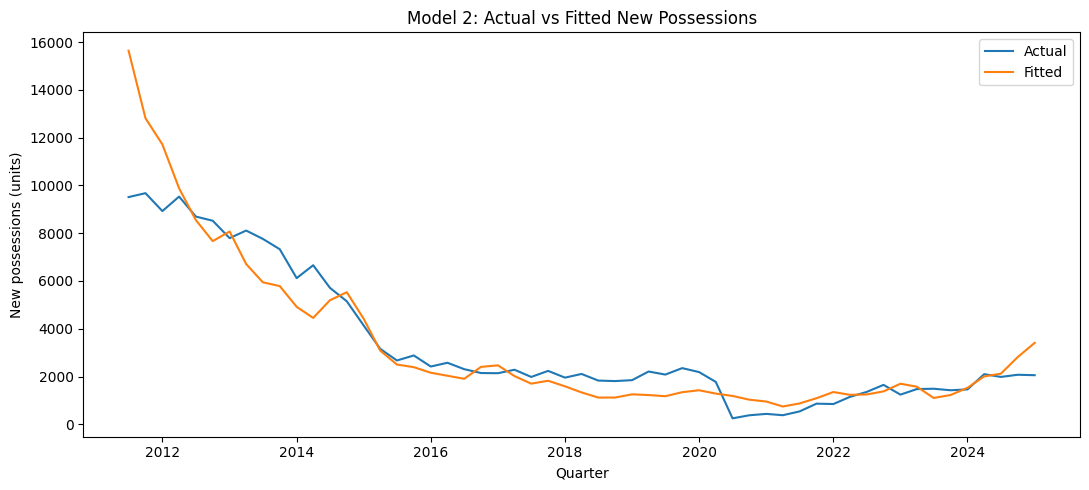

Saved tables:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\model2_new_possessions_coefficients.csv
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\tables\model2_new_possessions_fit_stats.csv

Saved summary:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper\model2_new_possessions_summary.txt

Saved figure:
- C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\outputs\figures\fig_07_model2_actual_vs_fitted_new_possessions.png

Model fit stats:
                      model_name  n_obs  r_squared  adj_r_squared        aic        bic
0  Model 2 - Log New Possessions     55   0.790228       0.764006  69.420894  83.472226

Coefficient table:
                             variable  coefficient  std_error_hac   t_value   p_value
0                               const     5.015796       1.650644  3.038690  0.002376
1         serious_arrears_rate_pct_l1     2.272435       0.509069  4.463906  0.000008
2  avg_interest_rate_all_loans_p

In [40]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
clean_dir = base / "data_clean"
tab_dir = base / "outputs" / "tables"
fig_dir = base / "outputs" / "figures"
paper_dir = base / "paper"

tab_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
paper_dir.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(clean_dir / "uk_mortgage_risk_final_research_dataset.csv").copy()

# Sort properly
df["year"] = df["period"].str[:4].astype(int)
df["quarter_num"] = df["period"].str[-1].astype(int)
df = df.sort_values(["year", "quarter_num"]).reset_index(drop=True)

# Quarter date for plotting
df["period_q"] = pd.PeriodIndex(df["period"], freq="Q")
df["period_date"] = df["period_q"].dt.to_timestamp(how="end")

# Target: log of new possessions
df["log_new_possessions_units"] = np.log1p(df["new_possessions_units"])

# Predictors for Model 2
predictors = [
    "serious_arrears_rate_pct",
    "avg_interest_rate_all_loans_pct",
    "uk_hpi_annual_change_pct",
    "fixed_rate_share_pct",
    "ltv_gt_90_pct",
    "gross_advances_gbp_m"
]

# Create 1-quarter lags
for col in predictors:
    df[f"{col}_l1"] = df[col].shift(1)

lagged_predictors = [f"{col}_l1" for col in predictors]

# Modeling dataset
model_df = df[["period", "period_date", "new_possessions_units", "log_new_possessions_units"] + lagged_predictors].dropna().copy()

X = model_df[lagged_predictors]
X = sm.add_constant(X)
y = model_df["log_new_possessions_units"]

# OLS with HAC robust standard errors
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

# Predictions in log scale and original scale
model_df["fitted_log_new_possessions_units"] = model.predict(X)
model_df["fitted_new_possessions_units"] = np.expm1(model_df["fitted_log_new_possessions_units"]).clip(lower=0)
model_df["residual_log"] = model_df["log_new_possessions_units"] - model_df["fitted_log_new_possessions_units"]

# Coefficient table
coef_table = pd.DataFrame({
    "variable": model.params.index,
    "coefficient": model.params.values,
    "std_error_hac": model.bse.values,
    "t_value": model.tvalues.values,
    "p_value": model.pvalues.values
})

coef_path = tab_dir / "model2_new_possessions_coefficients.csv"
coef_table.to_csv(coef_path, index=False)

# Fit stats
fit_table = pd.DataFrame([{
    "model_name": "Model 2 - Log New Possessions",
    "n_obs": int(model.nobs),
    "r_squared": model.rsquared,
    "adj_r_squared": model.rsquared_adj,
    "aic": model.aic,
    "bic": model.bic
}])

fit_path = tab_dir / "model2_new_possessions_fit_stats.csv"
fit_table.to_csv(fit_path, index=False)

# Save summary
summary_path = paper_dir / "model2_new_possessions_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(model.summary().as_text())

# Plot actual vs fitted in original units
plt.figure(figsize=(11, 5))
plt.plot(model_df["period_date"], model_df["new_possessions_units"], label="Actual")
plt.plot(model_df["period_date"], model_df["fitted_new_possessions_units"], label="Fitted")
plt.title("Model 2: Actual vs Fitted New Possessions")
plt.xlabel("Quarter")
plt.ylabel("New possessions (units)")
plt.legend()
plt.tight_layout()
fig_path = fig_dir / "fig_07_model2_actual_vs_fitted_new_possessions.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved tables:")
print("-", coef_path)
print("-", fit_path)

print("\nSaved summary:")
print("-", summary_path)

print("\nSaved figure:")
print("-", fig_path)

print("\nModel fit stats:")
print(fit_table)

print("\nCoefficient table:")
print(coef_table)

print("\nTop line interpretation:")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adj. R-squared: {model.rsquared_adj:.4f}")
print(f"Observations used: {int(model.nobs)}")

In [42]:
from pathlib import Path
import pandas as pd

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
tab_dir = base / "outputs" / "tables"
paper_dir = base / "paper"
paper_dir.mkdir(parents=True, exist_ok=True)

fit = pd.read_csv(tab_dir / "model2_new_possessions_fit_stats.csv")
coef = pd.read_csv(tab_dir / "model2_new_possessions_coefficients.csv")

r2 = float(fit.loc[0, "r_squared"])
adj_r2 = float(fit.loc[0, "adj_r_squared"])
n_obs = int(fit.loc[0, "n_obs"])

coef_no_const = coef[coef["variable"] != "const"].copy()
coef_no_const["sign"] = coef_no_const["coefficient"].apply(lambda x: "positive" if x > 0 else "negative")
coef_no_const["significance"] = coef_no_const["p_value"].apply(
    lambda p: "significant at the 1% level" if p < 0.01 else
              "significant at the 5% level" if p < 0.05 else
              "not statistically significant"
)

def row(var):
    return coef_no_const.loc[coef_no_const["variable"] == var].iloc[0]

r_arrears = row("serious_arrears_rate_pct_l1")
r_rate = row("avg_interest_rate_all_loans_pct_l1")
r_hpi = row("uk_hpi_annual_change_pct_l1")
r_fixed = row("fixed_rate_share_pct_l1")
r_ltv = row("ltv_gt_90_pct_l1")
r_gross = row("gross_advances_gbp_m_l1")

text = f"""# Model 2 Econometric Findings

## Econometric interpretation: new possessions model

Model 2 estimates the relationship between one-quarter-lagged mortgage-market conditions and the log of new mortgage possessions in the UK. The model has a reasonably strong overall fit, with an R-squared of {r2:.4f}, an adjusted R-squared of {adj_r2:.4f}, and {n_obs} quarterly observations.

The most important finding is that the lagged serious arrears rate is positively associated with new possessions and is {r_arrears["significance"]} (coefficient = {r_arrears["coefficient"]:.6f}, p = {r_arrears["p_value"]:.6f}). This is substantively important because it supports the idea that arrears distress tends to feed forward into possession activity in the following quarter.

The lagged share of lending above 90% loan-to-value is also positively associated with new possessions and is {r_ltv["significance"]} (coefficient = {r_ltv["coefficient"]:.6f}, p = {r_ltv["p_value"]:.6f}). This result is more in line with a conventional mortgage-risk interpretation, in which riskier leverage structures are associated with greater downstream stress.

By contrast, the lagged average interest rate on all loans is {r_rate["significance"]} in this specification (coefficient = {r_rate["coefficient"]:.6f}, p = {r_rate["p_value"]:.6f}). Lagged annual UK house-price growth is also {r_hpi["significance"]} (coefficient = {r_hpi["coefficient"]:.6f}, p = {r_hpi["p_value"]:.6f}), while the lagged fixed-rate share is {r_fixed["significance"]} (coefficient = {r_fixed["coefficient"]:.6f}, p = {r_fixed["p_value"]:.6f}), and lagged gross advances are likewise {r_gross["significance"]} (coefficient = {r_gross["coefficient"]:.6f}, p = {r_gross["p_value"]:.6f}).

Taken together, Model 2 suggests that possession activity is more directly tied to prior arrears stress than to all broader mortgage-market indicators simultaneously. In the paper, this should be interpreted as evidence that possessions are a later-stage manifestation of mortgage distress rather than simply a parallel market indicator.

Overall, Model 2 complements Model 1 well. Model 1 shows which lagged market conditions are associated with serious arrears, while Model 2 shows that lagged arrears themselves are strongly associated with subsequent possession activity. This gives the paper a coherent sequential story from mortgage-market conditions to arrears stress and then to enforcement outcomes.
"""

out_path = paper_dir / "model2_econometric_findings.md"
out_path.write_text(text, encoding="utf-8")

print(f"Saved: {out_path}\n")
print(text)

Saved: C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper\model2_econometric_findings.md

# Model 2 Econometric Findings

## Econometric interpretation: new possessions model

Model 2 estimates the relationship between one-quarter-lagged mortgage-market conditions and the log of new mortgage possessions in the UK. The model has a reasonably strong overall fit, with an R-squared of 0.7902, an adjusted R-squared of 0.7640, and 55 quarterly observations.

The most important finding is that the lagged serious arrears rate is positively associated with new possessions and is significant at the 1% level (coefficient = 2.272435, p = 0.000008). This is substantively important because it supports the idea that arrears distress tends to feed forward into possession activity in the following quarter.

The lagged share of lending above 90% loan-to-value is also positively associated with new possessions and is significant at the 5% level (coefficient = 0.250428, p = 0.036529). This res

In [44]:
from pathlib import Path

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
paper_dir = base / "paper"
paper_dir.mkdir(parents=True, exist_ok=True)

# Read the notes we already created
results_notes = (paper_dir / "results_section_notes.md").read_text(encoding="utf-8")
model1_notes = (paper_dir / "model1_econometric_findings.md").read_text(encoding="utf-8")
model2_notes = (paper_dir / "model2_econometric_findings.md").read_text(encoding="utf-8")

discussion_text = f"""# Findings and Discussion

## 1. Descriptive findings

The descriptive analysis shows that UK mortgage stress declined substantially over the sample, although it did not disappear. Serious arrears and total arrears were both materially higher in the early part of the period, while new possessions were also much higher in the early 2010s than in the later years. This suggests that the mortgage market moved from a relatively stressed phase to a more stable one over time.

The descriptive evidence also shows a marked structural shift in the composition of lending. Fixed-rate lending became much more prominent over time, while the aggregate mortgage market expanded in size. House-price growth also varied meaningfully across the sample, moving from weak or negative conditions in the early period to stronger positive growth in later years. These patterns suggest that mortgage distress should be understood within a broader macro-financial and product-structure setting rather than through arrears data alone.

## 2. Econometric findings from Model 1

Model 1 examined the relationship between one-quarter-lagged mortgage-market conditions and the serious arrears rate. The model fit was strong, indicating that lagged mortgage-market indicators explain a substantial share of the variation in serious arrears over the sample.

Three findings stand out. First, higher lagged mortgage interest rates were associated with higher serious arrears. Second, a higher lagged fixed-rate share was associated with lower serious arrears, which is consistent with the argument that fixed-rate borrowing can reduce short-run payment stress. Third, stronger lagged lending activity, as measured by gross advances, was associated with lower serious arrears, suggesting that healthier market conditions coincide with lower mortgage distress.

The coefficient on the lagged share of lending above 90 per cent loan-to-value was negative in this specification, which is not the simplest prior expectation. This result should therefore be interpreted carefully and not overstated. It may reflect broader market shifts, changing regulation, or time-pattern effects rather than a direct protective effect of high-LTV lending itself. By contrast, lagged house-price growth and lagged impaired-credit-history share did not emerge as statistically significant predictors in this model.

## 3. Econometric findings from Model 2

Model 2 examined the log of new mortgage possessions using one-quarter-lagged predictors. The model fit was weaker than Model 1 but still substantial, which is appropriate given that possession activity is a later-stage outcome and may depend on additional institutional or legal processes outside the model.

The key result is that lagged serious arrears were strongly and positively associated with later possession activity. This gives the paper an important sequential story: prior arrears stress feeds into later enforcement outcomes. In addition, the lagged share of lending above 90 per cent loan-to-value was positively associated with new possessions, which is more aligned with a standard mortgage-risk interpretation in which more highly leveraged lending is associated with greater downstream vulnerability.

Other mortgage-market indicators, including lagged interest rates, lagged house-price growth, lagged fixed-rate share, and lagged gross advances, were not statistically significant in Model 2 once lagged serious arrears were included. This suggests that possessions are more directly linked to prior distress than to the broader market environment all at once.

## 4. Integrated interpretation

Taken together, the two models provide a coherent empirical sequence. Model 1 suggests that serious arrears are associated with earlier pricing conditions, mortgage product structure, and overall market activity. Model 2 then shows that serious arrears themselves are strongly associated with subsequent possession activity. The combined implication is that mortgage distress appears to evolve in stages: broader mortgage-market conditions shape arrears stress, and arrears stress in turn shapes harder enforcement outcomes.

This sequential interpretation is valuable because it allows the paper to move beyond simple descriptive charts. It shows that the UK mortgage market is not only influenced by macro-financial conditions, but that these conditions appear to work through an identifiable distress channel. In particular, the rise of fixed-rate lending appears important in understanding the moderation of arrears risk, while higher-risk leverage structures remain relevant when explaining downstream possession outcomes.

## 5. Limits and caution

These results should be interpreted as associational rather than strictly causal. The sample is quarterly and relatively short, and several variables may share long-run trends. Possession outcomes may also be shaped by lender forbearance, court processes, and policy interventions that are not directly included in the present models. The negative coefficient on lagged high-LTV lending in Model 1 is a reminder that coefficients in aggregate time-series settings can reflect structural change and collinearity rather than simple mechanical effects.

Even so, the findings are still useful. They identify the variables most closely associated with arrears and possessions over the period studied and provide a defensible evidence base for the paper’s argument.

## 6. Main conclusion from the findings

The central empirical finding of the paper is that UK mortgage stress is best understood as a staged process. Lagged mortgage-market conditions, especially interest rates, fixed-rate penetration, and lending activity, are associated with serious arrears, while lagged arrears are in turn strongly associated with later possession activity. This provides a clear foundation for the final conclusion section of the paper.
"""

out_path = paper_dir / "findings_and_discussion_draft.md"
out_path.write_text(discussion_text, encoding="utf-8")

print(f"Saved: {out_path}\n")
print(discussion_text[:2500])

Saved: C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper\findings_and_discussion_draft.md

# Findings and Discussion

## 1. Descriptive findings

The descriptive analysis shows that UK mortgage stress declined substantially over the sample, although it did not disappear. Serious arrears and total arrears were both materially higher in the early part of the period, while new possessions were also much higher in the early 2010s than in the later years. This suggests that the mortgage market moved from a relatively stressed phase to a more stable one over time.

The descriptive evidence also shows a marked structural shift in the composition of lending. Fixed-rate lending became much more prominent over time, while the aggregate mortgage market expanded in size. House-price growth also varied meaningfully across the sample, moving from weak or negative conditions in the early period to stronger positive growth in later years. These patterns suggest that mortgage distress shou

In [46]:
from pathlib import Path

base = Path(r"C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research")
paper_dir = base / "paper"
paper_dir.mkdir(parents=True, exist_ok=True)

text = """# Introduction, Research Question, and Methodology

## 1. Introduction

Mortgage arrears and possession activity are among the clearest indicators of stress in a housing finance system. They matter not only because they reflect borrower distress, but also because they signal wider fragility in credit conditions, housing-market resilience, and the transmission of macro-financial pressures into household balance sheets. In the UK context, the mortgage market is especially important because of its scale, its connection to household wealth, and its sensitivity to changes in interest rates, lending standards, and property prices.

Over the past decade, the UK mortgage market has experienced substantial change. Lending composition shifted, fixed-rate products became more prominent, house-price growth moved through weaker and stronger phases, and aggregate mortgage distress fell from the elevated levels seen in the early 2010s. At the same time, risk did not disappear. Arrears and possession activity remained present, and their movement over time suggests that mortgage stress is shaped by a broader set of market conditions rather than by a single isolated factor.

This paper studies UK mortgage risk as a staged process. Rather than treating arrears and possessions as disconnected outcomes, it examines whether broader mortgage-market conditions are associated first with serious arrears and then with downstream possession activity. This approach makes it possible to move beyond descriptive trend reporting and toward an empirical account of how mortgage stress develops over time.

## 2. Research question

The main research question of the paper is:

**How are lagged mortgage-market conditions associated with serious mortgage arrears and subsequent possession activity in the UK?**

This main question is divided into two applied sub-questions:

1. Which one-quarter-lagged mortgage-market variables are most strongly associated with the serious mortgage arrears rate?
2. Does prior arrears stress help explain subsequent possession activity once broader mortgage-market variables are taken into account?

## 3. Research objectives

The paper has four objectives:

1. To construct a quarterly UK mortgage-risk dataset combining mortgage-market indicators, housing-market conditions, arrears measures, and possession outcomes.
2. To describe how UK mortgage stress evolved between 2011-Q1 and 2024-Q4.
3. To estimate whether lagged mortgage-market conditions are associated with the serious arrears rate.
4. To estimate whether lagged arrears stress is associated with later possession activity.

## 4. Data and sources

The empirical dataset is a quarterly panel covering 2011-Q1 to 2024-Q4. It combines variables derived from official UK mortgage and housing-market statistical releases. The final dataset contains mortgage pricing variables, lending composition measures, activity indicators, house-price growth, arrears measures, and possession outcomes.

The explanatory variables include the average interest rate on all loans, the share of fixed-rate lending, the share of high loan-to-value lending, the share of lending involving impaired credit history, gross advances, new commitments, and annual UK house-price growth. The main dependent variables are the serious arrears rate and new possessions.

The construction of a single quarterly dataset allows these market indicators to be analysed together in a common empirical framework.

## 5. Methodology

The analysis proceeds in three stages.

### 5.1 Descriptive analysis

The first stage uses descriptive statistics, yearly summaries, and visual trend analysis to identify the broad time pattern in arrears, possessions, lending activity, mortgage pricing, and house-price growth. This stage establishes the historical context for the econometric models.

### 5.2 Correlation analysis

The second stage uses Pearson correlations to identify the variables most closely associated with serious arrears, total arrears, and possession activity. These correlations are treated as exploratory and not causal. Their role is to guide model selection and identify the most relevant variables for formal estimation.

### 5.3 Econometric models

The third stage estimates two time-series regression models using one-quarter-lagged explanatory variables.

**Model 1** uses the serious mortgage arrears rate as the dependent variable. It tests whether lagged mortgage-market conditions, including interest rates, house-price growth, fixed-rate share, high-LTV lending, impaired-credit-history lending, and gross advances, are associated with later arrears.

**Model 2** uses the log of new possessions as the dependent variable. It tests whether possession activity is associated with lagged serious arrears and lagged mortgage-market conditions.

Both models are estimated using ordinary least squares with Newey-West heteroskedasticity and autocorrelation consistent standard errors. This choice is appropriate because the data are quarterly and serial dependence is a reasonable concern in aggregate mortgage-market time series.

## 6. Interpretation strategy

The paper interprets the results as associational rather than strictly causal. The purpose is not to claim that the estimated coefficients identify a fully causal effect, but to establish which lagged market conditions are most consistently linked with arrears and possession outcomes over the sample period. This is especially important in an aggregate quarterly setting, where institutional change, market structure, and common trends may all affect coefficient estimates.

## 7. Contribution of the paper

The paper makes a practical contribution by bringing together descriptive evidence, correlation analysis, and lagged econometric models in a single UK mortgage-risk framework. Its central contribution is to show that mortgage distress can be studied as a sequence: broader mortgage-market conditions are associated with arrears stress, and arrears stress is in turn associated with subsequent possession activity.

This staged interpretation provides a clearer analytical structure for understanding UK mortgage risk than a purely descriptive account of arrears or possessions alone.
"""

out_path = paper_dir / "introduction_research_question_methodology.md"
out_path.write_text(text, encoding="utf-8")

print(f"Saved: {out_path}\n")
print(text[:2500])

Saved: C:\Users\swapn\OneDrive\Desktop\UK_Mortgae_Risk_Research\paper\introduction_research_question_methodology.md

# Introduction, Research Question, and Methodology

## 1. Introduction

Mortgage arrears and possession activity are among the clearest indicators of stress in a housing finance system. They matter not only because they reflect borrower distress, but also because they signal wider fragility in credit conditions, housing-market resilience, and the transmission of macro-financial pressures into household balance sheets. In the UK context, the mortgage market is especially important because of its scale, its connection to household wealth, and its sensitivity to changes in interest rates, lending standards, and property prices.

Over the past decade, the UK mortgage market has experienced substantial change. Lending composition shifted, fixed-rate products became more prominent, house-price growth moved through weaker and stronger phases, and aggregate mortgage distress fel